---
numbering: false
---

# Chapter 0.2. Derivatives

Calculus is the study of **rates of change**, and without it, modern machine learning would not be possible. In many ways, machine learning is about **optimizing** quantities – making the _best_ possible predictions, or making prediction errors as _small_ as possible – and calculus is the tool that enables us to perform this optimization.

We'll address these lofty goals throughout the semester. Here, we will review key ideas from a first course in calculus (e.g. Math 115). Before proceeding, make sure you've read [Chapter 0.1. Summation Notation and the Mean](../00-prelim/01-summation.ipynb), as we'll use some of the notation from there.

## Tangent Lines

Suppose $f$ is a function that takes in a single real number and outputs a single real number, i.e. $f: \mathbb{R} \to \mathbb{R}$.

If $f$ is a function, then the **derivative** of $f$ is another function, sometimes denoted $f'$, such that $f'(x)$ is the "instantaneous" rate of change of $f$ at the input $x$.

To understand what I mean by "instantaneous" rate of change, let's consider an example. Suppose $f(x) = \frac{1}{4}x^2 - 3$. The graph of $f$ is shown below, in <span style="color: #3d81f6">blue</span>, along with a slider for input values of $x$. Drag the slider.




<!-- An intuitive definition of a derivative is a function's rate of change. For example, the derivative of a linear equation is the slope; the rate of change is constant across all values of $x$. However, nonlinear functions have derivatives which can vary with each value of $x$ - in other words, a function. We can use lines to help us find the rates of change, specifically tangent lines.

Recall that a tangent line is a line which touches a point on a graph and is parallel to the slope at that point. The fact that it's parallel is especially important, because finding the slope of the tangent line at $x$ also gives us the rate of change at $x$!  -->

In [1]:
from utils import plot_function_with_tangent_line

f = lambda x: (1/4)*x**2 - 3
f_prime = lambda x: (1/2)*x
x_range = (-6, 6)
y_range = (-6, 6)

fig = plot_function_with_tangent_line(f, f_prime, x_range, y_range)
fig.update_layout(width=600, height=500)

At any point $x$, the <span style="color:orange">tangent line (drawn in orange above)</span> to the graph of $f$ is the **best linear approximation** of the graph of $f$ near $x$.

For instance, drag the slider to $x=-4$. At $x = -4$, $f(-4) = \frac{1}{4}(-4)^2 - 3 = 1$.

The tangent line at $x=-4$ is the line that passes through the point $(-4, 1)$ that best approximates $f$ near $x=-4$, among all other lines that pass through $(-4, 1)$. In the plot above, use your mouse to zoom in on the point $(-4, 1)$, and you'll see that when zoomed in, the <span style="color:orange">tangent line</span> and <span style="color: #3d81f6">original function</span> are very difficult to distinguish.

:::{attention} The Derivative is the Slope of the Tangent Line

Here's the million dollar connection. The slope of the tangent line at $x$ **is, by definition**, the derivative of $f$ at $x$.

In the example above, when $x = -4$, the slope of the tangent line is $-2$, which is the derivative of $f$ at $x=-4$, i.e. $f'(-4) = -2$.
:::

This intuitive definition of the derivative – as being the slope of the tangent line – is the most important way to think about the derivative. The formal definition is also important, and we'll get there next, but you should have enough context for this first activity.

:::{tip} Activity 1
:class: dropdown <br>
Let $f(x) = \frac{1}{4}x^4 + \frac{1}{3}x^3 - x^2 + 2$.

Given that $f'(x)=x^3+x^2-2x$, find the equation of the tangent line to $f(x)$ at the following points:

- $x=-3$
- $x=-1$
- $x=1$

As a bonus exercise, try to verify that the provided formula for $f'(x)$ is correct, using your knowledge of derivatives from Calculus 1.
:::

---

## Formal Definition

### Secant Lines

Let's review the more formal definition of the derivative. First, remember the general formula for the slope of the line between two points $(x_1, y_1)$ and $(x_2, y_2)$: $$\frac{y_2 - y_1}{x_2 - x_1}$$

Let's say we're trying to find the slope of the tangent line at $x=a$, which is the line that passes through the point $(a, f(a))$ whose slope is the instantaneous rate of change of $f$ at $x=a$. To find that instantaneous rate of change, we can find the slope of the line between $(a, f(a))$ and some other point $(b, f(b))$, where $b-a$ is as close to $0$ as possible.

In the example below, as $b$ approaches $a = 1$, the slope of the line between $(1, f(1))$ and $(b, f(b))$ approaches the slope of the tangent line at $x=1$. Note that the formal name for the line between any two points on a function is a **secant line**.

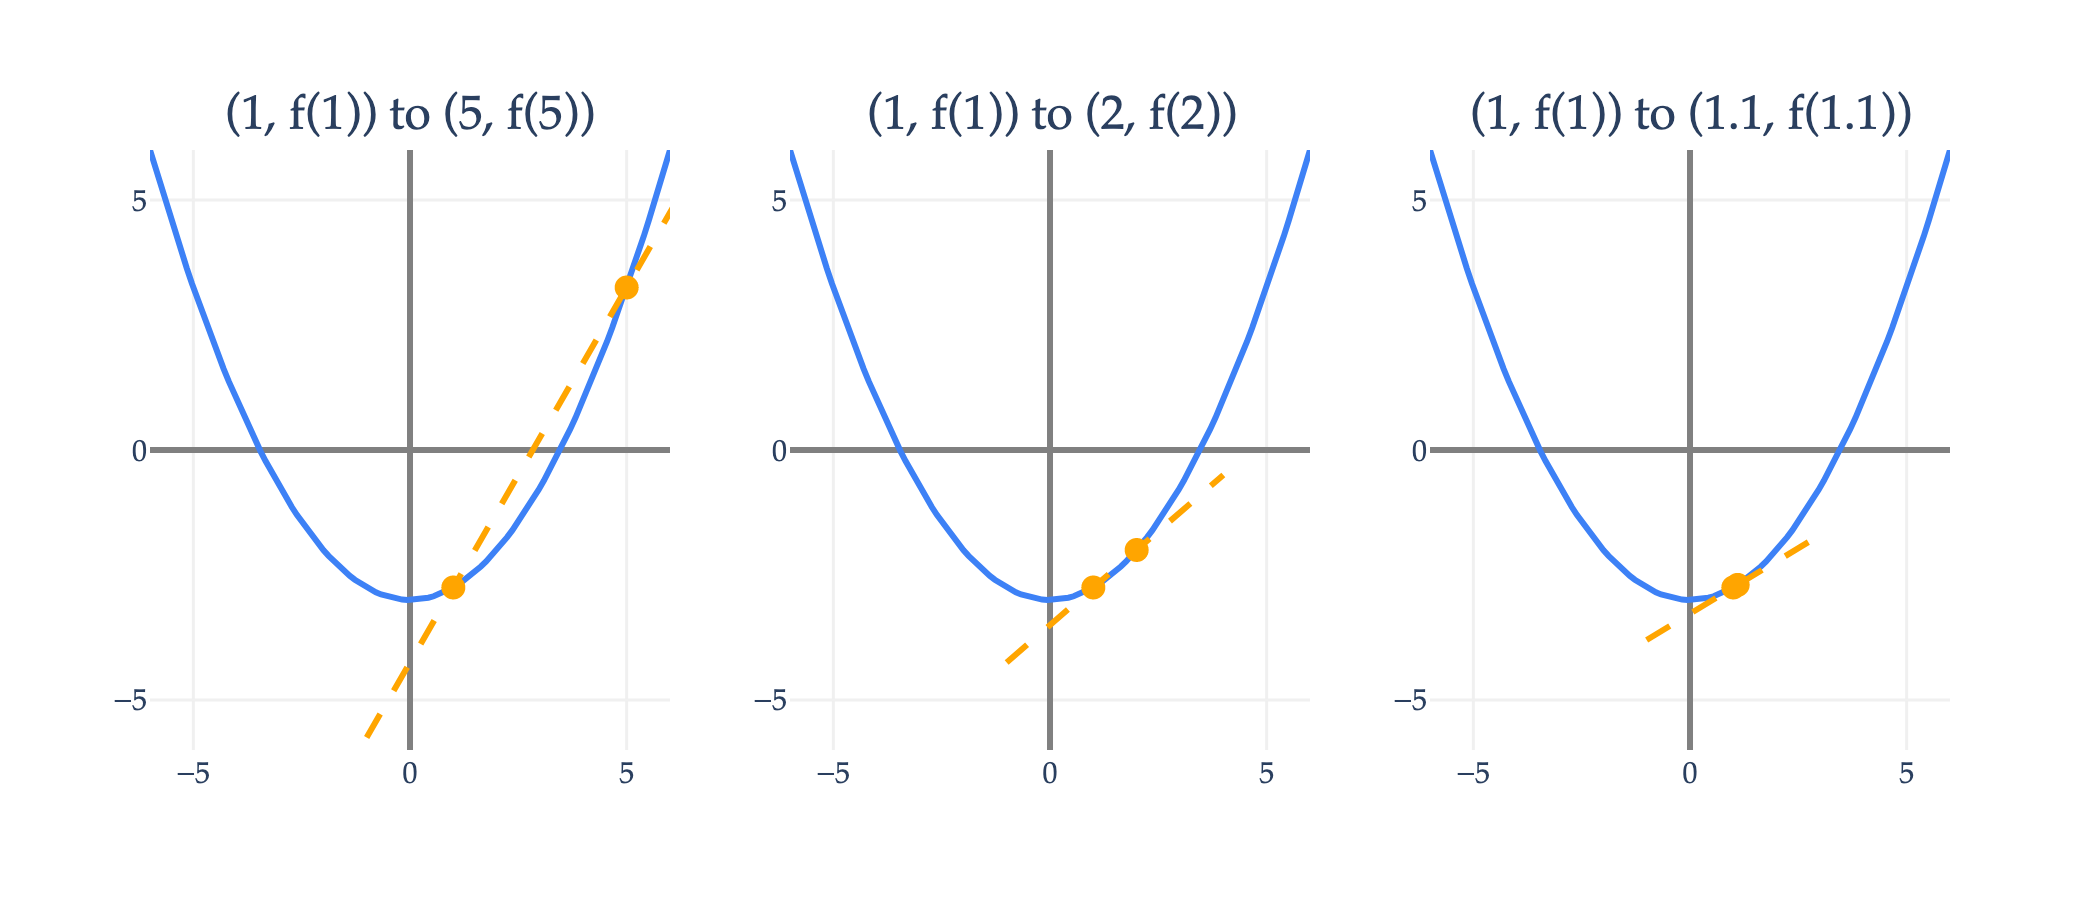

In [7]:
from utils import plot_multiple_secant_lines
import plotly
plotly.io.renderers.default = "png"

f = lambda x: (1/4)*x**2 - 3
x_range = (-6, 6)
y_range = (-6, 6)

# Define the three secant line pairs
secant_points = [
    (1, 5),      # Secant between 1 and 5
    (1, 2),     # Secant between 1 and 2 
    (1, 1.1)   # Secant between 1 and 2.1
]

fig = plot_multiple_secant_lines(f, secant_points, x_range, y_range)
fig.update_layout(width=700, height=300)
fig.show(scale=3)

### Limits

We can be more precise, using the idea of a **limit** from Calculus 1. Recall, if $\displaystyle \lim_{x \rightarrow a} g(x) = L$ means that as $x$ gets closer and closer to $a$, $g(x)$ gets closer and closer to $L$. (Intuitively, you might think that the limit of $g(x)$ as $x$ approaches $a$ is always just $g(a)$, but that's not always the case.)

The slope of the tangent line at $x=a$ is the limit of the slope of the line between $(a, f(a))$ and $(b, f(b))$ as $b$ approaches $a$:

$$\text{slope of tangent line at } a = \lim_{b \to a}\frac{f(b)-f(a)}{b-a}$$

This definition alone can help us compute some common derivatives. For instance, if $f(x) = x^2$, then the slope of the tangent line at $x=a$ is:

$$\lim_{b \to a}\frac{f(b)-f(a)}{b-a} = \lim_{b \to a}\frac{b^2-a^2}{b-a} = \lim_{b \to a}\frac{(b-a)(b+a)}{b-a} = \lim_{b \to a}(b+a) = 2a$$

Here, we used the difference of squares formula, $b^2 - a^2 = (b-a)(b+a)$.

Instead of thinking of the slope of the tangent line as the limit of the slope of the line between $(a, f(a))$ and $(b, f(b))$ as $b \rightarrow a$, a more general (and equivalent!) definition of the derivative is the limit of the slope of the line between $(x, f(x))$ and $(x+h, f(x+h))$ as $h \rightarrow 0$.

### Definition

:::{note} Definition: Derivative

Suppose $f: \mathbb{R} \to \mathbb{R}$ is a function. Then the **derivative** of $f$ at $x$ is defined as:

$$\frac{\text{d}f}{\text{d}x}(x) = \lim_{h \to 0}\frac{f(x+h)-f(x)}{h}$$

This is pronounced "the derivative of $f$ with respect to $x$."
:::

We will not use this formal definition much in this class, but it's good to understand where it comes from and why it works.

There are two equivalent notations for the derivative: $\frac{\text{d}f}{\text{d}x}(x)$ and $f'(x)$. We used the notation $f'(x)$ in the previous section since it's easier to write and more commonly used in calculus courses. However, we'll use the notation $\frac{\text{d}f}{\text{d}x}(x)$ from now on, as it'll make the transition to multivariable calculus more natural when we get there.

Often, for brevity, we will drop the $(x)$ and just write $\frac{\text{d}f}{\text{d}x}$. As an example, suppose $g(x) = \sin^2(x) + 3 \log (x)$, where $\log$ is the natural logarithm (with base $e$). Then, the derivative of $g$ is:

$$\frac{\text{d}g}{\text{d}x} = 2\sin(x)\cos(x) + \frac{3}{x}$$

$\frac{\text{d}g}{\text{d}x}$ (equivalently, $\frac{\text{d}g}{\text{d}x}(x)$) is a function, not a number. To get a number as an output, we need to plug in a value for $x$. For example, $\frac{\text{d}g}{\text{d}x}(\pi)$ is the number ($\frac{3}{\pi}$) corresponding to the slope of the tangent line to $g$ at $x=\pi$.

To actually find $\frac{\text{d}g}{\text{d}x}$, we used several derivative rules. Let's recap.

---

## Rules and Examples

:::{note} Five Key Derivative Rules
1. **Constant Rule**: If $f(x) = c$, where $c$ is some constant, then:

    $$\frac{\text{d}f}{\text{d}x} = 0$$

1. **Addition Rule**: If $h(x) = f(x) + g(x)$, then:

    $$\frac{\text{d}h}{\text{d}x} = \frac{\text{d}f}{\text{d}x} + \frac{\text{d}g}{\text{d}x}$$

    Equivalently, $h'(x) = f'(x) + g'(x)$.

1. **Power Rule**:

    $$\frac{\text{d}}{\text{d}x}x^n = nx^{n-1}$$

1. **Product Rule**: If $h(x) = f(x)g(x)$, then:

    $$\frac{\text{d}h}{\text{d}x} = f \cdot \frac{\text{d}g}{\text{d}x} + \frac{\text{d}f}{\text{d}x} \cdot g$$

    Equivalently, $h'(x) = f(x) g'(x) + f'(x) g(x)$.

1. **Chain Rule**: If $h(x) = f(g(x))$, then:

    $$\frac{\text{d}h}{\text{d}x} = \frac{\text{d}f}{\text{d}g} \cdot \frac{\text{d}g}{\text{d}x}$$

    Equivalently, $h'(x) = f'(g(x)) g'(x)$.

:::

These rules can all be proved using the formal definition of the derivative, but we won't emphasize those proofs here.

Attempt each of the following examples before peeking at their solutions.

### Example: Polynomials

Differentiate $f(x) = 4x^5 + 3x^2 + 2x + 1$.

:::{seealso} Solution
:class: dropdown

None of the five key rules directly specify how to take the derivative of an expression like $4x^5$, and even though you _may_ look at this expression and see that its derivative is $20 x^4$, it's well worth our time to review the rules carefully. 

Let's split $4x^5$ into two separate functions, $4$ and $x^5$, and then use the product rule.

$$\frac{\text{d}}{\text{d}x} 4x^5 = 4 \left( \frac{\text{d}}{\text{d}x} x^5 \right) + \left( \frac{\text{d}}{\text{d}x}4 \right) x^5 = 4 \cdot 5x^4 + 0 = 20x^4$$

While applying the product rule, we also used the power rule to differentiate $x^5$, and the constant rule to differentiate $4$.

With this in mind, we can return to the goal of differentiating $f(x)$.

$$
\begin{align*}
\frac{\text{d}f}{\text{d}x} &= \frac{\text{d}}{\text{d}x} (4x^5 + 3x^2 + 2x + 1) \\
&= \frac{\text{d}}{\text{d}x} 4x^5 + \frac{\text{d}}{\text{d}x} 3x^2 + \frac{\text{d}}{\text{d}x} 2x + \frac{\text{d}}{\text{d}x} 1 \\
&= 20x^4 + 6x + 2
\end{align*}
$$
:::

### Example: Reciprocals

Differentiate $f(x) = \frac{1}{x^2 - 1}$.

:::{seealso} Solution
:class: dropdown

Note that $f(x)$ can also be written as $f(x) = (x^2 - 1)^{-1}$, which looks like something we can use the power rule on. To fully apply the power rule, we'll need to use the chain rule, too.

$$
\begin{align*}
\frac{\text{d}}{\text{d}x} (x^2 - 1)^{-1} &= \underbrace{-1 \cdot (x^2 - 1)^{-2}}_{\text{power rule}} \:\:\:\: \cdot \underbrace{\frac{\text{d}}{\text{d}x} (x^2 - 1)}_{\text{required by the chain rule}} \\
&= -1 \cdot (x^2 - 1)^{-2} \cdot 2x \\
&= -\frac{2x}{(x^2 - 1)^2}
\end{align*}
$$

:::

### Example: Quotients

Differentiate $f(x) = \frac{x^2 + 1}{x^2 - 1}$.

:::{seealso} Solution
:class: dropdown

It looks like $f(x)$ is a quotient of two functions, $x^2 + 1$ and $x^2 - 1$, but I intentionally did not introduce a quotient rule – it's unnecessary, and can be replicated using the product rule and chain rule, since $f(x)$ can be written as a product:

$$
f(x) = \frac{x^2 + 1}{x^2 - 1} = (x^2 + 1) \cdot \frac{1}{x^2 - 1}
$$

You'll notice that we've already found the derivative of $\frac{1}{x^2 - 1}$ in Example 2, so we can use that result here while applying the product rule.

$$
\begin{align*}
\frac{\text{d}f}{\text{d}x} &= \frac{\text{d}}{\text{d}x} \left( (x^2 + 1) \cdot \frac{1}{x^2 - 1} \right) \\
&= \underbrace{\left( \frac{\text{d}}{\text{d}x} (x^2 + 1) \right) \cdot \frac{1}{x^2 - 1} + (x^2 + 1) \cdot \left( \frac{\text{d}}{\text{d}x} \frac{1}{x^2 - 1} \right)}_{\text{product rule}} \\
&= 2x \cdot \frac{1}{x^2 - 1} + (x^2 + 1) \cdot \underbrace{\left( -\frac{2x}{(x^2 - 1)^2} \right)}_{\text{from Example 2}} \\
&= \frac{2x}{x^2 - 1} - \frac{2x(x^2 + 1)}{(x^2 - 1)^2} \\
&= \underbrace{\frac{2x(x^2 - 1) - 2x(x^2 + 1)}{(x^2 - 1)^2}}_{\text{common denominator}} \\
&= \frac{2x(x^2 - 1 - x^2 - 1)}{(x^2 - 1)^2} \\
&= \frac{-4x}{(x^2 - 1)^2}
\end{align*}
$$
:::

### Example: Trigonometric and Logarithmic Functions

Differentiate $f(x) = \log(\cos(e^x))$.

To do so, you'll need to remember a few other common derivatives that the five key rules don't cover.

1. **Trigonometric Derivatives**: 

    $$\frac{\text{d}}{\text{d}x} \sin(x) = \cos(x)$$
    $$\frac{\text{d}}{\text{d}x} \cos(x) = -\sin(x)$$

1. **Logarithmic Derivatives**: If $\log$ is the natural logarithm (with base $e$), then:

    $$\frac{\text{d}}{\text{d}x} \log(x) = \frac{1}{x}$$
    $$\frac{\text{d}}{\text{d}x} \log_b(x) = \frac{1}{x \log(b)}$$

1. **Exponential Derivatives**:

    $$\frac{\text{d}}{\text{d}x} e^x = e^x$$
    $$\frac{\text{d}}{\text{d}x} a^x = a^x \log(a)$$

:::{seealso} Solution
:class: dropdown

Differentiating $f(x) = \log(\cos(e^x))$ requires a few careful applications of the chain rule.

$$
\begin{align*}
\frac{\text{d}f}{\text{d}x} &= \frac{\text{d}}{\text{d}x} \log(\cos(e^x)) \\
&= \frac{1}{\cos(e^x)} \cdot \frac{\text{d}}{\text{d}x} \cos(e^x) \\
&= \frac{1}{\cos(e^x)} \cdot (-\sin(e^x)) \cdot \frac{\text{d}}{\text{d}x} e^x \\
&= \frac{1}{\cos(e^x)} \cdot (-\sin(e^x)) \cdot e^x \\
&= -\frac{e^x \sin(e^x)}{\cos(e^x)} \\
&= -e^x \tan(e^x)
\end{align*}
$$
:::

The chain rule is **extremely** pervasive in machine learning, which is why I've included examples like the one above. [This site](https://math.libretexts.org/Bookshelves/Calculus/Calculus_(OpenStax)/03%3A_Derivatives/3.06%3A_The_Chain_Rule) contains dozens more examples of the chain rule in practice.

:::{tip} Activity 2
:class: dropdown

Note that the activities in this section are quite challenging, so make sure you've attempted and fully understood the examples above first.

**Activity 2.1**

An important function in machine learning is the **sigmoid function**, which is defined as:

$$
\sigma(x) = \frac{1}{1 + e^{-x}}
$$

$\sigma(x)$ has a nice S-shape, and is used for predicting probabilities.

Find the derivative of $\sigma(x)$, and show that it satisfies the following property:

$$
\frac{\text{d}}{\text{d}x} \sigma(x) = \sigma(x) (1 - \sigma(x))
$$

**Activity 2.2**

Find the derivative of each of the following functions:

- $f(x) = \sqrt{\sin(4\pi x)}$
- $g(x) = (2x + 1)^{3x}$ (Hint: Start by taking the natural logarithm of both sides, then take the derivative of both sides.)

**Activity 2.3**

Suppose $x$ and $y$ satisfy the following relationship:

$$x^2 = y^3 - 11$$

1. Find an expression for $\frac{\text{d}y}{\text{d}x}$ that involves **both** $x$ and $y$. To do this, don't solve for $y$ in terms of $x$ – instead, take the derivative of both sides of the equation with respect to $x$, use the power and chain rules, and re-arrange to isolate $\frac{\text{d}y}{\text{d}x}$.
2. Find the slope of the tangent line to the curve at the point $(x, y) = (4, 3)$.
:::

---

## Optimization

### Maxima and Minima

As stated at the start of this section, calculus is a tool for optimization – that is, finding the inputs that maximize or minimize a function. Let's be more precise about what we mean by "maximize" and "minimize".

Consider $f(x) = \frac{1}{4}x^4 + \frac{1}{3} x^3 - x^2 + 2$, shown below.

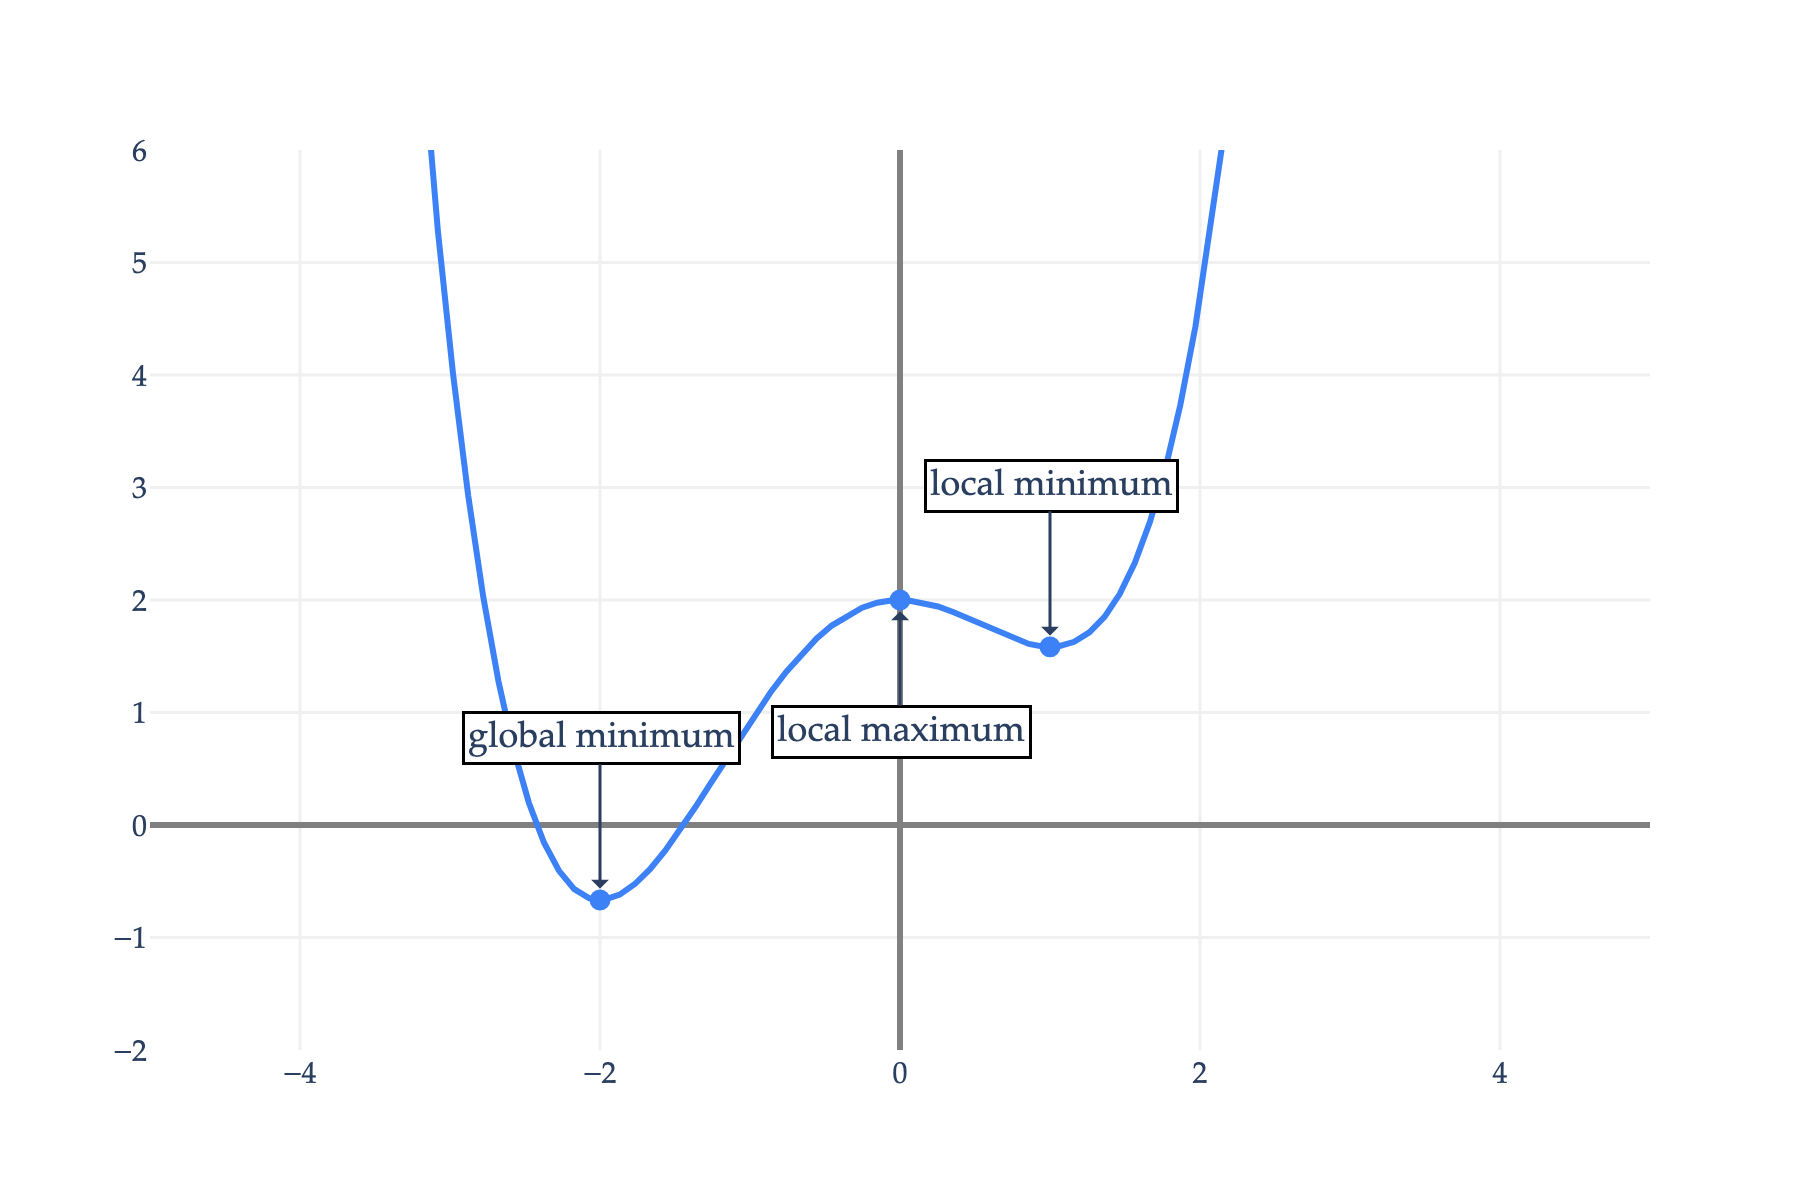

In [7]:
from utils import plot_functions
import plotly
plotly.io.renderers.default = 'png'

f_list = [lambda x: (1/4)*x**4 + (1/3)*x**3 - x**2 + 2]
f_titles = ['f(x)=x^4/4+x^3/3-x^2+2']
crit_x = [-2, 0, 1]
crit_labels = ['global minimum', 'local maximum', 'local minimum']
x_range = (-5, 5)
y_range = (-2, 6)

fig = plot_functions(f_list, f_titles, crit_x, x_range, y_range)
fig.update_layout(width=600, height=400)

# Annotate f(x) for x in crit_x with the label (x, f(x))
f = lambda x: (1/4)*x**4 + (1/3)*x**3 - x**2 + 2
for i, x in enumerate(crit_x):
    y = f(x)
    fig.add_annotation(
        x=x,
        y=y + 0.1 * (1 if i % 2 == 0 else -1),
        text=crit_labels[i],
        showarrow=True,
        arrowhead=1,
        ax=0,
        ay=[-50, 40, -50][i],
        bgcolor="white",
        bordercolor="black",
        borderwidth=1
    )

fig.show(scale=3)

Where is $f(x)$ maximized and minimized?

- At $x=-2$, $f(x)$ is less than it is at all other inputs. This is means $(-2, f(-2))$ is a **global minimum**.
- At $x=0$, $f(x)$ _looks like_ it is greater than all other inputs, but only if you restrict your attention to points near $x=0$. This means $(0, f(0))$ is a **local maximum**. $(0, f(0))$ is not a **global maximum** because there are plenty of points where $f(x) > f(0)$ – they are just not immediately adjacent to $x=0$.
- Similarly, $(1, f(1))$ is a **local minimum**.

$f(x)$ does not have a global maximum, since $f(x)$ approaches infinity as $x$ increases beyond $x=1$ or decreases beyond $x=-2$. If we were to restrict the domain (or set of possible inputs) of $f(x)$ to, say, $[-3, 3]$, then there would be a global maximum at $x=3$.

Note that we usually care more about the inputs that maximize or minimize a function, rather than the actual values of the function at those inputs. In the above example, the fact that $x=-2$ is a global minimum is important; the fact that $f(-2) = -\frac{2}{3}$ is not _as_ important.

To recap:

:::{note} Definition: Maxima and Minima

Suppose $f: \mathbb{R} \to \mathbb{R}$ is a function.

On maxima:
- A function $f: \mathbb{R} \to \mathbb{R}$ has a **local maximum** at $x=a$ if $f(a) \geq f(x)$ for all $x$ in some interval around $a$.
- A function $f: \mathbb{R} \to \mathbb{R}$ has a **global maximum** at $x=a$ if $f(a) \geq f(x)$ for all $x$ in the domain of $f$.

Intuitively, a local maximum is a point where the function is higher than all nearby points, and a global maximum is a point where the function is higher than all points in the domain.

On minima:
- A function $f: \mathbb{R} \to \mathbb{R}$ has a **local minimum** at $x=a$ if $f(a) \leq f(x)$ for all $x$ in some interval around $a$.
- A function $f: \mathbb{R} \to \mathbb{R}$ has a **global minimum** at $x=a$ if $f(a) \leq f(x)$ for all $x$ in the domain of $f$.

:::

Note that maxima is the plural of maximum, minima is the plural of minimum, and extrema refers to both maxima and minima.

### Critical Points

As you'll remember from calculus, the derivative plays a crucial role in helping us find the locations of extrema.

:::{note} Definition: Critical Point

A **critical point** of a function $f: \mathbb{R} \to \mathbb{R}$ is a point $x=a$ where $\frac{\text{d}}{\text{d}x}f(a)=0$ or $\frac{\text{d}}{\text{d}x}f(a)$ is undefined.

Let's revisit the function $f(x) = \frac{1}{4}x^4 + \frac{1}{3} x^3 - x^2 + 2$, shown in <span style="color: #3d81f6;">blue</span> along with its derivative, $\frac{\text{d}}{\text{d}x}f(x) = x^3 + x^2 - 2x$, shown in <span style="color: orange;">orange</span>.

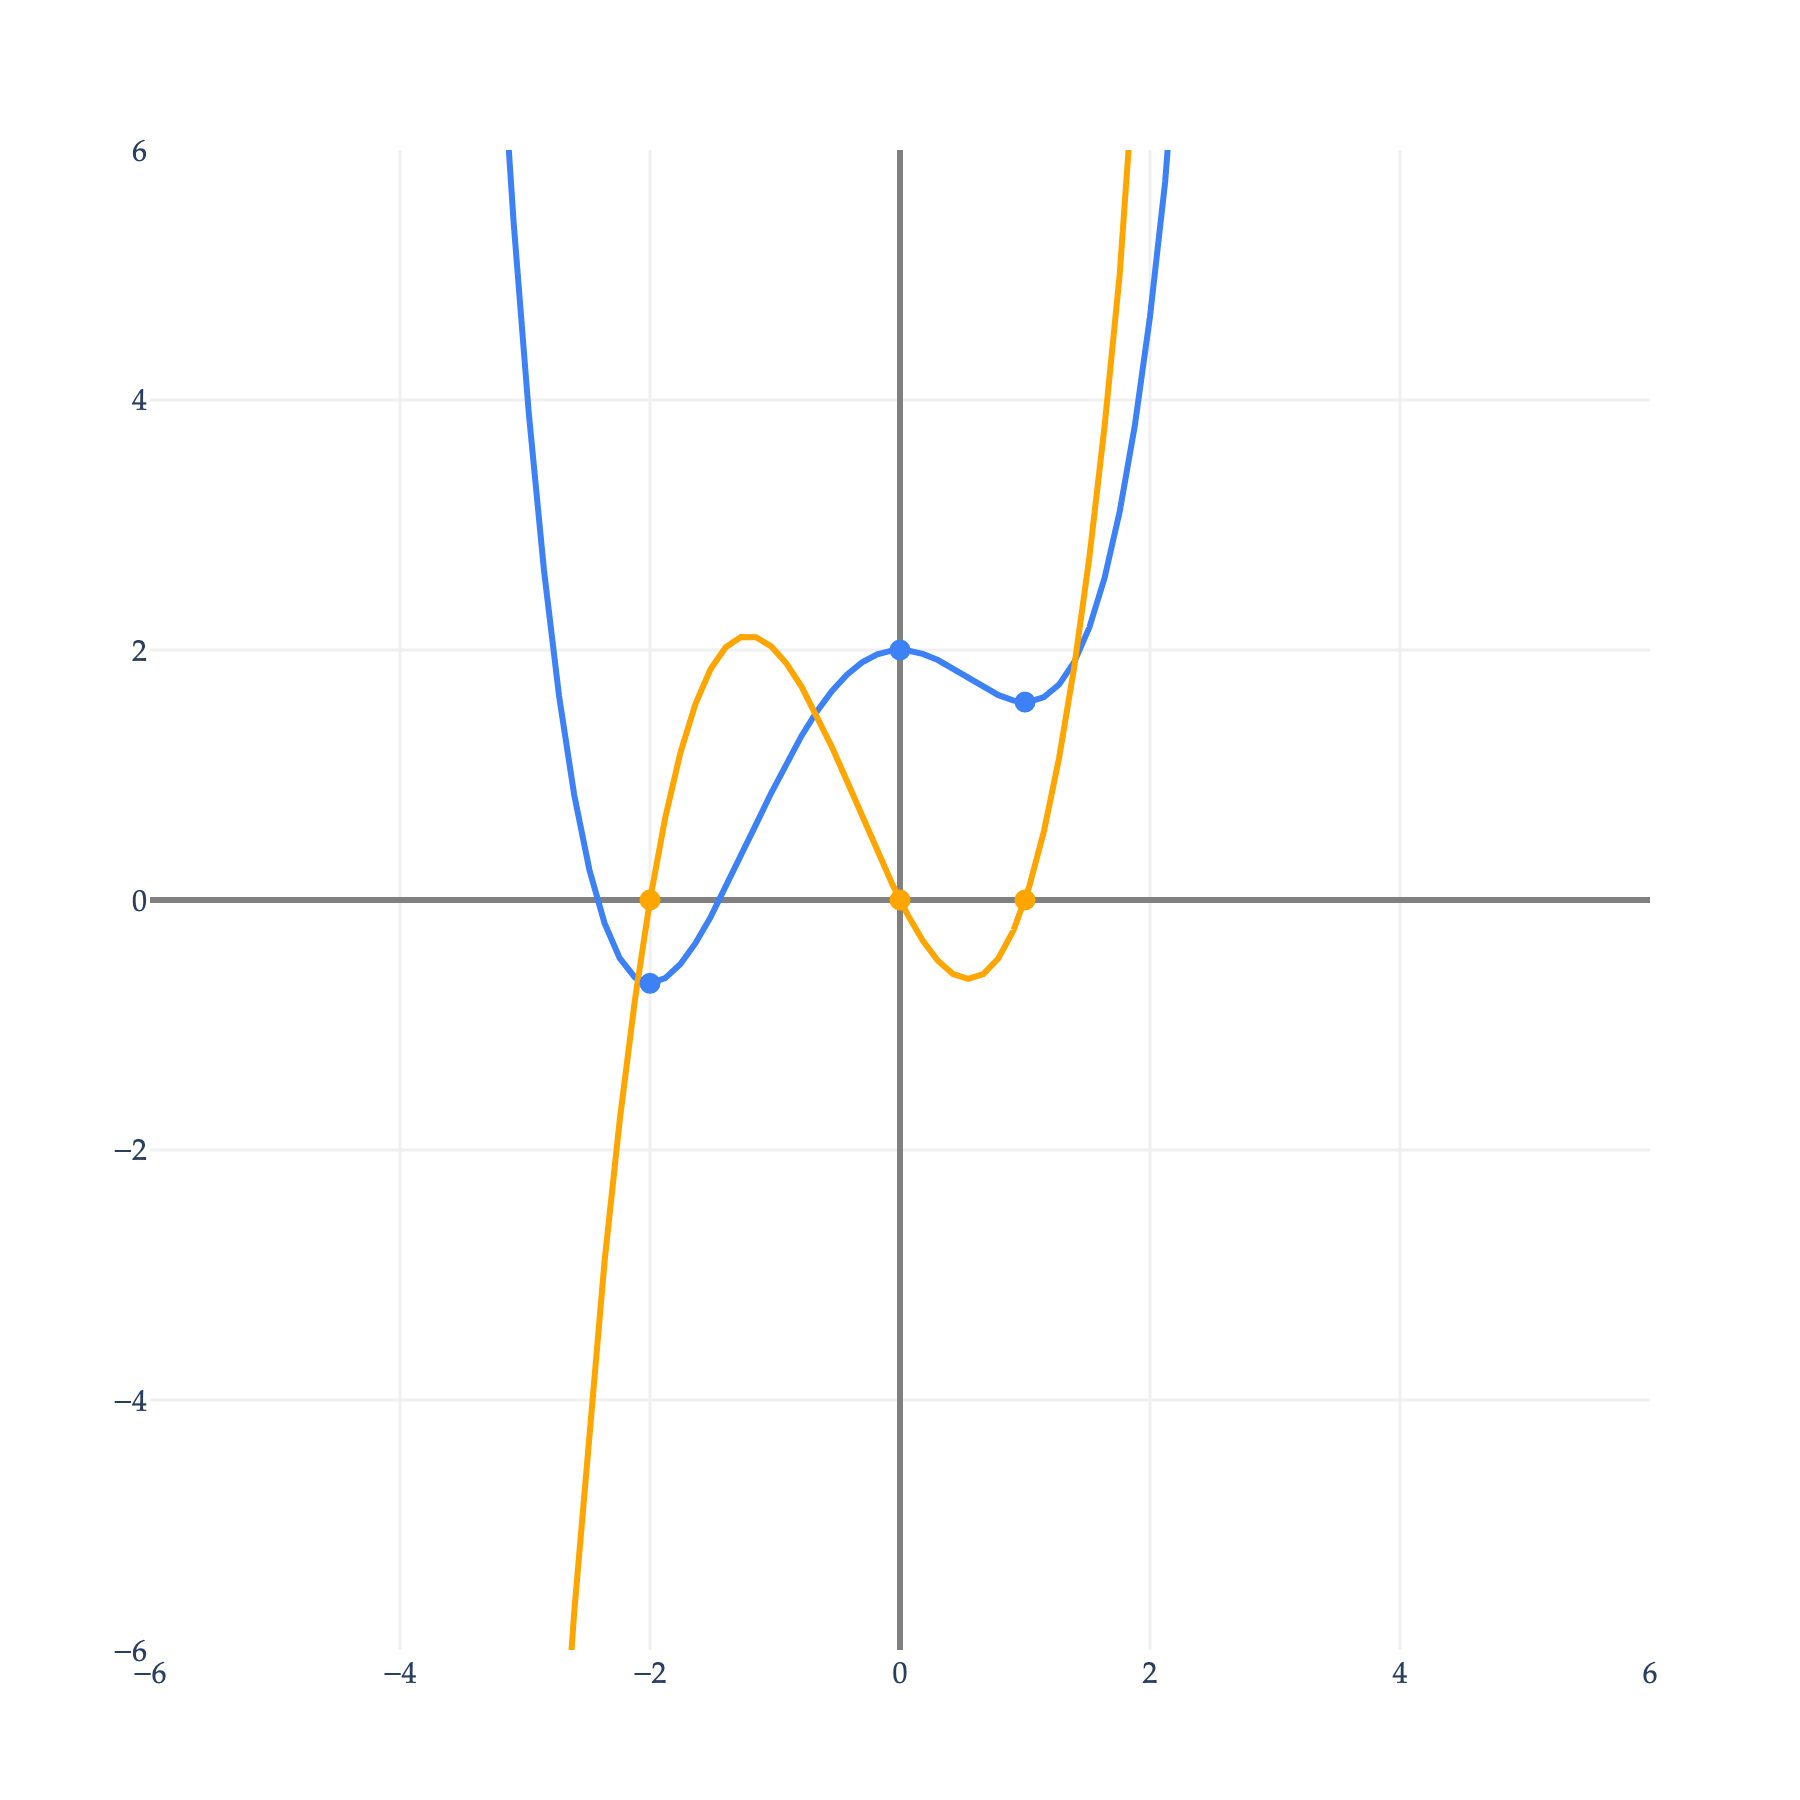

In [8]:
from utils import plot_functions
import plotly
plotly.io.renderers.default = 'png'

f_list = [lambda x: (1/4)*x**4 + (1/3)*x**3 - x**2 + 2, lambda x: x**3 + x**2 - 2*x]
f_titles = ['f(x)=x^4/4+x^3/3-x^2+2', 'f\'(x)=x^3+x^2-2x']
crit_x = [-2, 0, 1]
x_range = (-6, 6)
y_range = (-6, 6)

fig = plot_functions(f_list, f_titles, crit_x, x_range, y_range)
fig.show(scale=3)

We can see from the graph above that $f(x)$ has the following extrema:
- global minimum at $x=-2$
- a local maximum at $x=0$
- a local minimum at $x=1$

:::{tip} Activity 4
:class: dropdown
Using the graph and intuitive definition of $\frac{\text{d}}{\text{d}x}f(x)$, explain the placement of each of $f(x)$'s critical points.

*Hint: think about what it means for $\frac{\text{d}}{\text{d}x}f(x)$ to be negative, 0, and positive*
:::

A key use case for critical points is in optimization problems, where you want to find the maximum or minimum value given some constraints.  

It's completely possible for functions to not have any global or local extrema, or any extrema at all. For example, our graph above doesn't have a global maximum, since the function infinitely increasing for all $x<-2$ and $x>1$. The plots below are some additional examples of functions with varying amounts and types of extrema.

In [3]:
from utils import plot_functions_grid
import numpy as np
f_0 = lambda x: x**3 + 1
f_1 = lambda x: -x**2
f_2 = lambda x: x**3 - 3*x
f_3 = lambda x: x**4 - 4*x**2
f_4 = lambda x: np.exp(x)
f_5 = lambda x: x
f_list = [f_0, f_1, f_2, f_3, f_4, f_5]
f_titles = ["y=x³+1<br>No Extrema", 
            "y=-x²<br>Global Max",
            "y=x³-3x<br>Local Max & Min", 
            "y=x⁴-4x²<br>Local Max, 2 Local Min<br>(also 2 Global Min)",
            "y=e^x<br>No Extrema",
            "y=x<br>No Extrema"]
x_range = (-4, 4)
y_range = (-4, 4)
plot_functions_grid(f_list, f_titles, x_range=x_range, y_range=y_range, rows=3, cols=2)

## Finding Extrema and the Second Derivative
Now that we know what extrema are and why they're useful, let's go over how we can find them and identify their type. We'll start by reviewing the second derivative, as it's important for this.

The second derivative $\frac{\text{d}^2}{\text{d}x^2}f(x)$ the the rate at which $\frac{\text{d}}{\text{d}x}f(x)$ is changing. In other words, the derivative of $\frac{\text{d}}{\text{d}x}f(x)$. This can be difficult to visualize, so let's go over a helpful analogy for understanding the second derivative.

:::{tip} Activity 5
:class: dropdown
You're driving down a straight road. If $f(x)$ is position you are at on the road at time $x$, what is $\frac{\text{d}}{\text{d}x}f(x)$? What about $\frac{\text{d}^2}{\text{d}x^2}f(x)$?

Given information about $\frac{\text{d}}{\text{d}x}f(x)$ and $\frac{\text{d}^2}{\text{d}x^2}f(x)$, describe the behavior of $f(x)$ at time $x$ and explain your reasoning in terms of the car analogy.
- $\frac{\text{d}}{\text{d}x}f(x) > 0, \frac{\text{d}^2}{\text{d}x^2}f(x) > 0$
- $\frac{\text{d}}{\text{d}x}f(x) > 0, \frac{\text{d}^2}{\text{d}x^2}f(x) < 0$
- $\frac{\text{d}}{\text{d}x}f(x) < 0, \frac{\text{d}^2}{\text{d}x^2}f(x) > 0$
- $\frac{\text{d}}{\text{d}x}f(x) < 0, \frac{\text{d}^2}{\text{d}x^2}f(x) < 0$
:::

Another way of thinking about $\frac{\text{d}^2}{\text{d}x^2}f(x)$ is that it can tell us about the curvature of a graph. Let's reexamine $f(x)$ from earlier to see how:

In [4]:
from utils import plot_functions
import numpy as np
f_list = [lambda x: (1/4)*x**4 + (1/3)*x**3 - x**2 + 2, lambda x: x**3 + x**2 - 2*x, lambda x: 3*x**2 + 2*x - 2]
f_titles = ['f(x)', 'f\'(x)', 'f\'\'(x)']
x_range = (-6, 6)
y_range = (-6, 6)

plot_functions(f_list, f_titles, x_range=x_range, y_range=y_range)

# TODO: add a flag for which graphs to initially show, this way it's less overwhelming

Recall that $f(x)$ has critical points at $x=-2,0,1$. We can use these to split the graph into sections and analyze each one:
- $x<-2$: $f(x)$ is decreasing because $\frac{\text{d}}{\text{d}x}f(x)<0$. We can also see that $\frac{\text{d}^2}{\text{d}x^2}f(x)>0$ and is quite large, which explains the steep curve of $\frac{\text{d}}{\text{d}x}f(x)$ as it approaches $x=-2$. As $\frac{\text{d}}{\text{d}x}f(x)$ approaches 0, the curve of $f(x)$ becomes less steep, and eventually flattens for a local minimum at $x=2$
- $-2<x<0$: $f(x)$ is increasing because $\frac{\text{d}}{\text{d}x}f(x)>0$. $\frac{\text{d}^2}{\text{d}x^2}f(x)$ is also positive, explaining positive slope of $\frac{\text{d}}{\text{d}x}f(x)$. However, at around $x=1.2$, $\frac{\text{d}^2}{\text{d}x^2}f(x)$ hits zero and starts going negative. This causes $\frac{\text{d}}{\text{d}x}f(x)$ to decrease until $x=0$. We can see the impact of this on $f(x)$ as its curve becomes less steep as it approaches $x=0$, and eventually flattens to a local maximum at $x=0$.
- $0<x<1$: $f(x)$ is once again decreasing because $\frac{\text{d}}{\text{d}x}f(x)<0$. The rate of its decrease (in other words, the absolute value of $\frac{\text{d}}{\text{d}x}f(x)$) is small, so the curve isn't steep. At around $x=0.55$ the second derivative hits 0 and becomes positive after, causing $\frac{\text{d}}{\text{d}x}f(x)0$ to increase and hit 0 at $x=1$, giving us another local minimum.
- $x>1$: $f(x)$ is now increasing because $\frac{\text{d}}{\text{d}x}f(x)>0$. $\frac{\text{d}^2}{\text{d}x^2}f(x)$ is not only positive but very large, causing $\frac{\text{d}}{\text{d}x}f(x)$'s to sharply increase and $f(x)$'s curve to be very steep.

This understanding of how the second derivative affects the curve of a function is the basis of the second derivative test. We use it to determine if a critical point is an extremum, and if so, what type! 


### Definition
:::{note} Definition: Second Derivative Test
At a critical point where $\frac{\text{d}}{\text{d}x}f(x)=0$, there are 3 possibilities:
- $\frac{\text{d}^2}{\text{d}x^2}f(x)>0$: local minimum
- $\frac{\text{d}^2}{\text{d}x^2}f(x)<0$: local maximum
- $\frac{\text{d}^2}{\text{d}x^2}f(x)=0$: inconclusive
:::

:::{tip} Activity 6
:class: dropdown
Given the function $R(h) = \frac{1}{3} \left( (3 - h)^2 + (4 - h)^2 + (11-h)^2 \right)$:
- What is the derivative?
- What are the critical points?
- Are the critical points extrema? If so, what type, and what does it tell us about $R(h)$?
:::

## Continuity and Undefined Derivatives

### Definition
:::{note} Definition: Continuity
A function $f(x)$ is continuous at a point $x=a$ is defined if all of these conditions are met:
1. $f(a)$ is defined
2. The limits of $f(x)$ approaching $x=a$ from the left and right sides are defined and equal, $\lim_{x \to a^-}f(x)=\lim_{x \to a^+}f(x)=f(a)$
3. $\lim_{x \to a}f(x)=f(a)$
Continuity can also be evaluated on an interval, where if all points within the interval are continuous then it is as well.
:::

Consider the following functions with discontinuities:

In [5]:
from utils import plot_functions_grid
import numpy as np

f_list = [lambda x: 1/x, lambda x: x**3]
f_titles = ["f(x)=1/x", "g(x)=x^3 <br>for all x < 1 and x > 1"]
f_excludes = [0, 1]
x_range = (-4, 4)
y_range = (-4, 4)
plot_functions_grid(f_list, f_titles, f_excludes=f_excludes, x_range=x_range, y_range=y_range, rows=1, cols=2)

In [11]:
from utils import plot_piecewise

f_list = [lambda x: x**2, lambda x: x+2]
intervals = [(-4, -0.01), (0, 4)]
plot_piecewise(f_list, intervals, x_range=(-4, 4), y_range=(-4, 4), title="h(x)=x^2 for x < 0 and x+2 for x >= 0")

$f(x)$ is pretty straight forward, as $1/0$ is undefined, the function has a discontinuity at $x=0$. $g(x)$ is a bit more subtle, with the function being undefined at $x=1$ from it's definition. We call this kind of discontinuity a hole because the function looks like a normal graph of $x^3$ (thanks to the second condition being true), but the point is undefined. The third function, $h(x)$ has a clear discontinuity in the sudden jump from the interval $(-\infty, 0)$ to $[0, \infty)$, violating both the second and third conditions.

So why does continuity matter? It turns out that if the function is differentiable at a point, then it's continuous at that point.  

:::{note} Definition: When is the Derivative Defined?
The derivative of a function $f(x)$ is defined at a point $x=a$ is defined if all of these conditions are met:
1. $f(a)$ is defined
2. The derivatives of $f(x)$ approaching $x=a$ from the left and right sides are defined and equal.
3. $\frac{\text{d}}{\text{d}x}f(a)$ is finite
:::

From this definition, we can see that $f(0)$ and $g(1)$ are not differentiable because they're undefined. $h(0)$ is also undifferentiable because the derivative from the left approaches $0$, while the right side is $1$, violating the second condition. 

:::{tip} Activity 7
:class: dropdown
Given the function $f(x)=|x|$:
- Is the function continuous? 
- Is the derivative undefined at any points? If so, which points and why? Explain using the definition above.
:::

## Summations

Since the addition rule states that the derivative of a sum is the sum of the derivatives, we can also think of this in terms of summations:

$$F(x) = \sum_{i=1}^n f_i(x)$$

$$\frac{d}{dx} F(x) = \sum_{i=1}^n \frac{d}{dx} f_i(x)$$

:::{tip} Activity 3
:class: dropdown
Find the derivatives of each of the following functions:
- $f(x) = \sum_{k=1}^4 kx^k$
- $f(h) = \sum_{i=1}^n (x_i - h)^2$,  note that $f$ is a function of $h$, not $x_i$!
- Given $f_1(x)=\frac{1}{x^2}$, $f_2(x)=(x-2)^2(x+1)$, $f_3(x)=6x^2 + 3x$:<br>$F(x) = \sum_{i=1}^n f_i(x)$